## Revision 2


Compute the tSNR and the ncSNR.

In [2]:
import pandas as pd
import nibabel as nib
import sys
import numpy as np
from tqdm.notebook import trange

# Add .. to the system path to import from the parent directory
sys.path.append("..")

from convergence.nsd import load_mask, get_resource
from convergence.plotting import plot_faverage_parcelation

import matplotlib.pyplot as plt

## Compute average ncsnr



Compute the average ncSNR from the NSD dataset, averaging voxel-wise responses using taking averages per HCP rois.

Source files: "ncsnr-sub-0{subject}.nii.gz"

In [ ]:

join_hemispheres = False
for join_hemispheres in [False, True]:
    snr_stats = []
    for subject in trange(1, 8 + 1):
        mask = load_mask(subject=subject, roi="both.HCP_MMP1")
        filename = f"snr/ncsnr-sub-0{subject}.nii.gz"
        data = nib.load(filename).get_fdata()
        
        total_rois = 360 if join_hemispheres else 180
        for roi in range(1, total_rois + 1):
            if join_hemispheres:
                mask_roi = (mask == roi) | (mask == roi + 180)
            else:
                mask_roi = (mask == roi)
            snr = data[mask_roi]
            snr_stats.append({
                "roi": roi,
                "subject": subject,
                "mean_snr": np.mean(snr),
                "std_snr": np.std(snr),
                "num_voxels": len(snr),
                "join_hemispheres": join_hemispheres
            })

    df = pd.DataFrame(snr_stats)
    suffix = "_joined" if join_hemispheres else "_separate"
    df.to_parquet(f"snr_stats{suffix}.parquet", index=False)

Preview the results

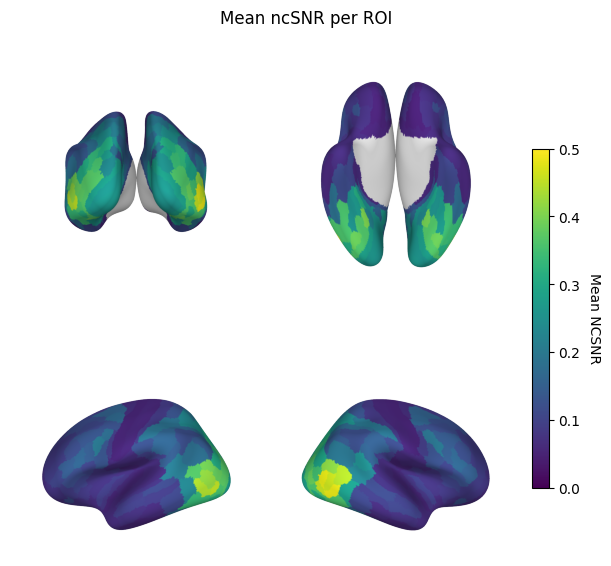

In [29]:
df = pd.read_parquet("snr_stats_joined.parquet")
df = df.groupby("roi").agg({
    "mean_snr": "mean",
    "std_snr": "mean",
    "num_voxels": "mean"
}).reset_index()
df = df.merge(get_resource("hcp")[["roi", "mne_name"]])



cmap="viridis"

vrange = (0, 0.5)
brain = plot_faverage_parcelation(
    df,
    value_column="mean_snr",
    normalize=vrange,
    default_color="lightgray",
    default_value=None,
    cmap=cmap,
)


fig, axes = plt.subplots(2, 2, figsize=(6, 6), constrained_layout=True)
axes = axes.flatten()
fig.suptitle("Mean ncSNR per ROI")

for ax, view in zip(axes, ["caudal", "ventral", "lateral", "medial"]):
    brain.show_view(view)
    ax.imshow(brain.screenshot(mode="rgba"), aspect="equal")
    ax.axis("off")

brain.close()

# Add a colorbar to the last ax
norm = plt.Normalize(vmin=vrange[0], vmax=vrange[1])
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes.ravel().tolist(), shrink=0.6, pad=0.02)
cbar.set_label("Mean NCSNR", rotation=270, labelpad=15)

## Compute tSNR


Compute the tSNR using the BOLD series of the first session of each subject, and averaging per ROI.

In [7]:
filename_template = "/home/pablomm/Desktop/tsnr/subj{subject:02d}/func1mm/timeseries/timeseries_session{session:02d}_run{run:02d}.nii.gz"


def get_filename_bold(subject=1, session=1, run=1):
    return filename_template.format(subject=subject, session=session, run=run)

def compute_tsnr(filename):
    data = nib.load(filename).get_fdata()

    mean_signal = np.mean(data, axis=-1)
    safe_std = np.std(data, axis=-1)

    tsnr = np.divide(
        mean_signal,
        safe_std,
        out=np.zeros_like(mean_signal, dtype=np.float32),
        where=safe_std != 0,
    )
    tsnr = np.nan_to_num(tsnr, nan=0.0, posinf=0.0, neginf=0.0)
    return tsnr

def mean_per_roi(data, subject=1, roi="both.HCP_MMP1"):
    mask = load_mask(subject=subject, roi=roi)
    roi_stats = []
    for roi_id in np.unique(mask[mask>0]):
        roi_mask = (mask == roi_id)
        roi_data = data[roi_mask]
        # safe, exclude possible NaN or inf values
        roi_data = roi_data[np.isfinite(roi_data)]
        num_voxels = len(roi_data)
        mean_value = np.mean(roi_data) if num_voxels > 0 else 0.0
        std_value = np.std(roi_data) if num_voxels > 0 else 0.0
        roi_stats.append({
            "subject": subject,
            "roi": roi_id,
            "mean_value": mean_value,
            "std_value": std_value,
            "num_voxels": num_voxels,
            "mask": roi
        })
    return pd.DataFrame(roi_stats)

In [ ]:
all_tsnr_stats = []
for subject in trange(1, 8 + 1):
    runs_data = []
    for run in range(1, 12 + 1):
        filename = get_filename_bold(subject=subject, session=1, run=run)
        tsnr = compute_tsnr(filename)
        runs_data.append(tsnr)

    runs_data = np.stack(runs_data, axis=-1)
    mean_tsnr = np.mean(runs_data, axis=-1)
    df_tsnr = mean_per_roi(mean_tsnr, subject=subject, roi="both.HCP_MMP1")
    df_tsnr = df_tsnr.merge(get_resource("hcp")[["roi", "mne_name"]], on="roi")
    all_tsnr_stats.append(df_tsnr)

In [ ]:
df_all_tsnr_stats = pd.concat(all_tsnr_stats)
df_all_tsnr_stats.to_parquet("tsnr_stats_all.parquet", index=False)

Preview the results

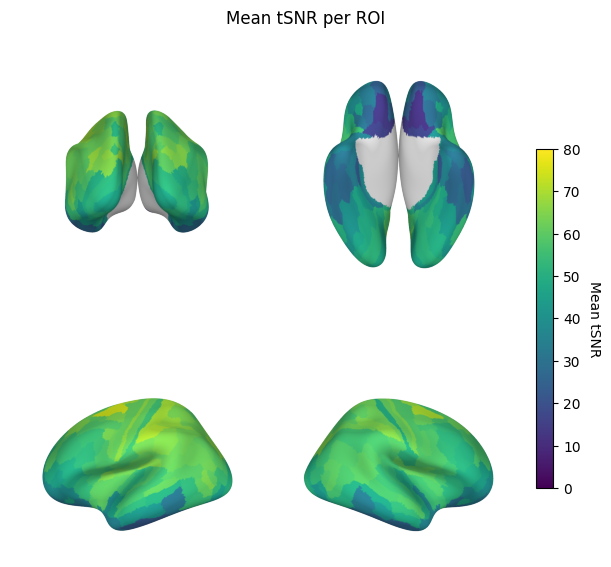

In [ ]:
df_all_tsnr_stats = pd.read_parquet("tsnr_stats_all.parquet")
cmap="viridis"

vrange = (0, 80)
brain = plot_faverage_parcelation(
    df_all_tsnr_stats.groupby(["roi", "mne_name"])
    .agg({"mean_value": "mean"})
    .reset_index(),
    value_column="mean_value",
    normalize=vrange,
    default_color="lightgray",
    default_value=None,
    cmap=cmap,
)


fig, axes = plt.subplots(2, 2, figsize=(6, 6), constrained_layout=True)
axes = axes.flatten()
fig.suptitle("Mean tSNR per ROI")

for ax, view in zip(axes, ["caudal", "ventral", "lateral", "medial"]):
    brain.show_view(view)
    ax.imshow(brain.screenshot(mode="rgba"), aspect="equal")
    ax.axis("off")

brain.close()

# Add a colorbar to the last ax
norm = plt.Normalize(vmin=vrange[0], vmax=vrange[1])
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes.ravel().tolist(), shrink=0.6, pad=0.02)
cbar.set_label("Mean tSNR", rotation=270, labelpad=15)